# Predicting Nonlinear Gain as f(n, m, l, S)

Goal: Find a closed-form function that predicts nonlinear_gain from architecture parameters.

**Approach:**
1. Generate a comprehensive dataset sweeping (n, m, l, S) with multiple seeds
2. Explore which transformed variables are most predictive
3. Fit parametric functional forms with increasing complexity
4. Validate on held-out configurations
5. Interpret the best-fit function physically

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit, differential_evolution
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
import torch
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

from core import (
    Autoencoder, generate_sparse_data, train_autoencoder,
    measure_encoding_linearity, run_experiment, device
)

print(f"Using device: {device}")

Using device: cpu


## 1. Generate Dataset

Sweep over (n, m, l, S) with 3 seeds per config to average out optimization noise.
Use `core.py` functions for consistency with main notebook.

In [2]:
# Sweep already completed via run_sweep.py
# Grid: n=[16,32,64,128,256], m=[2,4,8,16,32,64], l=[1,2,3,4], S=[0.85,0.9,0.95]
# 3 seeds per config, 5000 steps, best seed (lowest loss) selected
pass

In [3]:
# Sweep already completed - skip
pass

In [4]:
# Sweep already saved - skip
pass

## 2. Explore Relationships

Before fitting, visualize how nonlinear_gain depends on each variable.

In [5]:
# Load from CSV (sweep already completed via run_sweep.py)
df = pd.read_csv('metric_prediction_data.csv')
print(f"Loaded {len(df)} rows")
print(f"Nonlinear gain range: [{df['nonlinear_gain'].min():.4f}, {df['nonlinear_gain'].max():.4f}]")
print(f"Mean gain std across seeds: {df['gain_std'].mean():.4f}")

n_seeds = 3
n_steps = 5000

Loaded 288 rows
Nonlinear gain range: [-0.0010, 0.5088]
Mean gain std across seeds: 0.0132


In [6]:
# Add derived features for exploration
df['ratio'] = df['n'] / df['m']
df['log_ratio'] = np.log(df['n'] / df['m'])
df['active'] = (1 - df['S']) * df['n']  # expected active features
df['active_per_dim'] = df['active'] / df['m']
df['log_n'] = np.log(df['n'])
df['log_m'] = np.log(df['m'])
df['log_active'] = np.log(df['active'])
df['excess'] = (df['active'] - df['m']).clip(lower=0)  # features that don't fit linearly
df['excess_frac'] = df['excess'] / df['active']  # fraction of features that need superposition

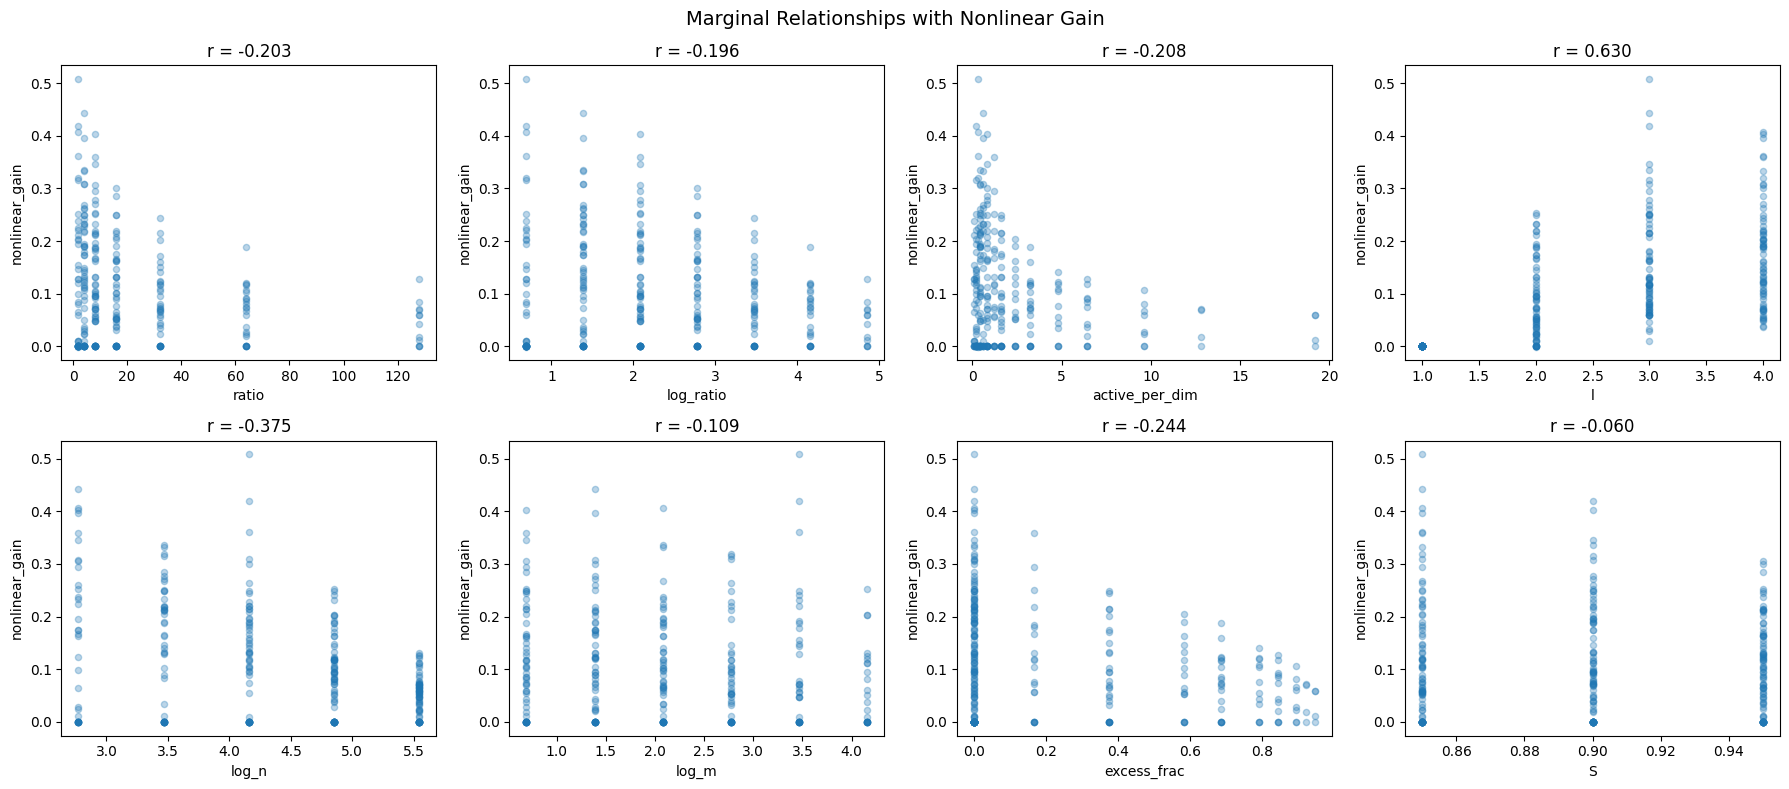

In [7]:
# Marginal relationships
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

predictors = ['ratio', 'log_ratio', 'active_per_dim', 'l',
              'log_n', 'log_m', 'excess_frac', 'S']

for ax, pred in zip(axes.flat, predictors):
    ax.scatter(df[pred], df['nonlinear_gain'], alpha=0.3, s=20)
    # Add correlation
    r = df[pred].corr(df['nonlinear_gain'])
    ax.set_xlabel(pred)
    ax.set_ylabel('nonlinear_gain')
    ax.set_title(f'r = {r:.3f}')

plt.suptitle('Marginal Relationships with Nonlinear Gain', fontsize=14)
plt.tight_layout()
plt.show()

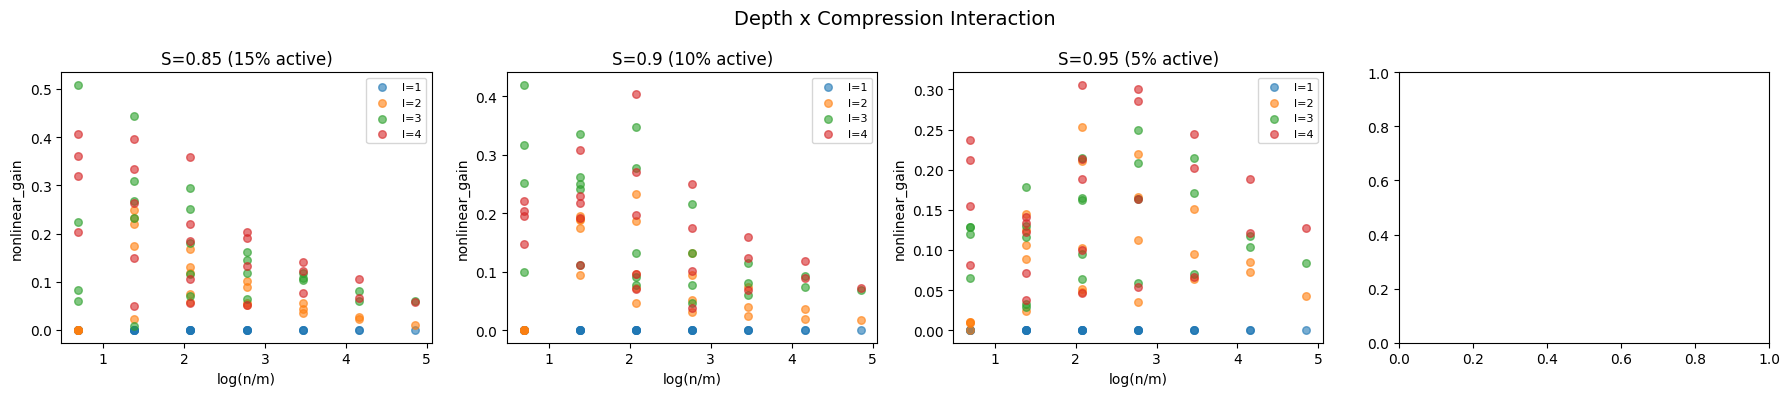

In [8]:
# Key question: does depth (l) interact with compression?
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, S in zip(axes.flat, sorted(df['S'].unique())):
    sub = df[df['S'] == S]
    for l in sorted(sub['l'].unique()):
        sub_l = sub[sub['l'] == l]
        ax.scatter(sub_l['log_ratio'], sub_l['nonlinear_gain'], 
                   label=f'l={l}', alpha=0.6, s=30)
    ax.set_xlabel('log(n/m)')
    ax.set_ylabel('nonlinear_gain')
    ax.set_title(f'S={S} ({100*(1-S):.0f}% active)')
    ax.legend(fontsize=8)

plt.suptitle('Depth x Compression Interaction', fontsize=14)
plt.tight_layout()
plt.show()

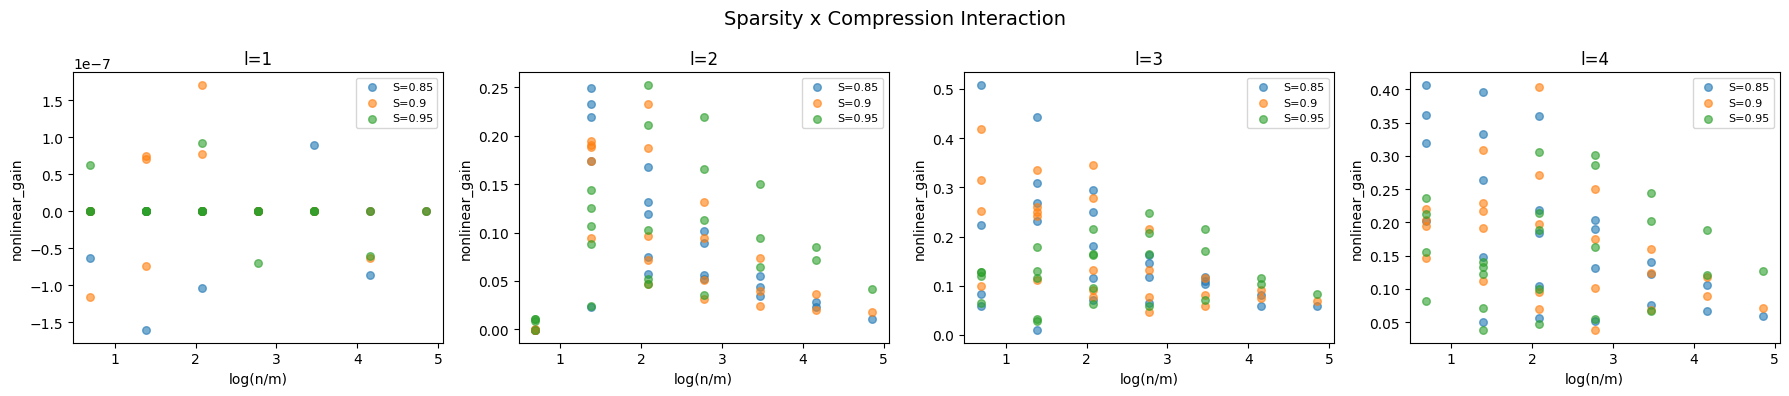

In [9]:
# How does sparsity interact with compression?
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, l in zip(axes.flat, sorted(df['l'].unique())):
    sub = df[df['l'] == l]
    for S in sorted(sub['S'].unique()):
        sub_S = sub[sub['S'] == S]
        ax.scatter(sub_S['log_ratio'], sub_S['nonlinear_gain'],
                   label=f'S={S}', alpha=0.6, s=30)
    ax.set_xlabel('log(n/m)')
    ax.set_ylabel('nonlinear_gain')
    ax.set_title(f'l={l}')
    ax.legend(fontsize=8)

plt.suptitle('Sparsity x Compression Interaction', fontsize=14)
plt.tight_layout()
plt.show()

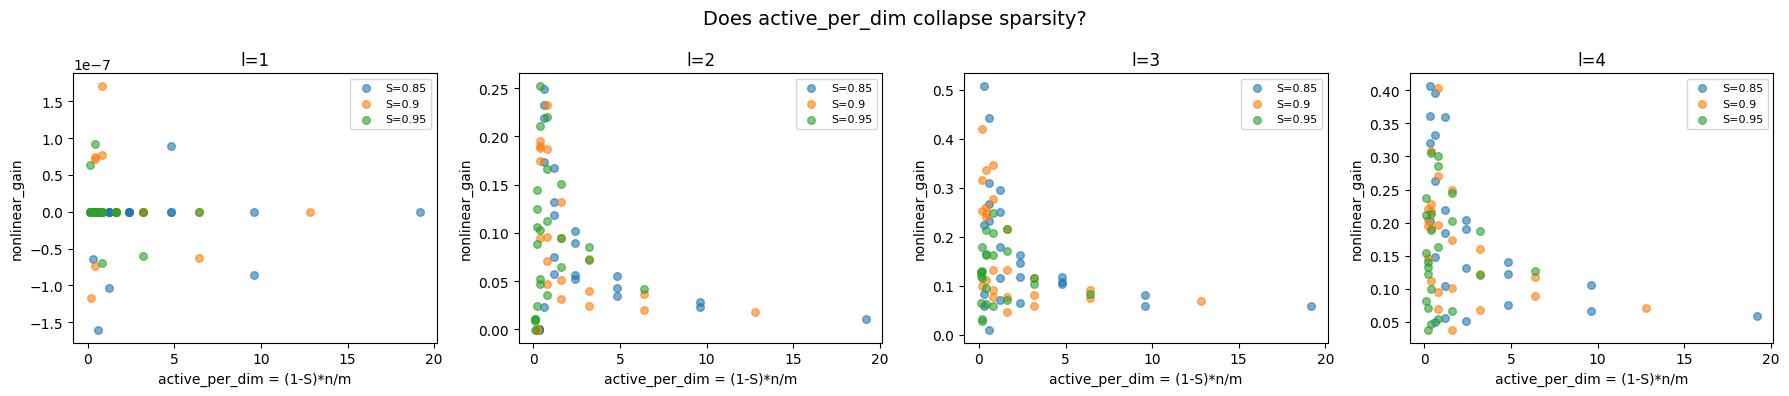

In [10]:
# Does active_per_dim collapse across sparsity levels?
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, l in zip(axes.flat, sorted(df['l'].unique())):
    sub = df[df['l'] == l]
    for S in sorted(sub['S'].unique()):
        sub_S = sub[sub['S'] == S]
        ax.scatter(sub_S['active_per_dim'], sub_S['nonlinear_gain'],
                   label=f'S={S}', alpha=0.6, s=30)
    ax.set_xlabel('active_per_dim = (1-S)*n/m')
    ax.set_ylabel('nonlinear_gain')
    ax.set_title(f'l={l}')
    ax.legend(fontsize=8)

plt.suptitle('Does active_per_dim collapse sparsity?', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Shape Analysis & Variance Decomposition

Before fitting, understand the structure of the data.

In [11]:
# Shape analysis: gain vs active_per_dim by depth
print("=== SHAPE: Mean gain by active_per_dim bin and depth ===\n")
df_analysis = df.copy()
df_analysis['apd_bin'] = pd.cut(df_analysis['active_per_dim'], bins=[0, 0.5, 1, 2, 4, 8, 20])

for l_val in sorted(df['l'].unique()):
    sub = df_analysis[df_analysis['l'] == l_val]
    print(f"l={l_val}: overall mean = {sub['nonlinear_gain'].mean():.4f}")
    for name, grp in sub.groupby('apd_bin', observed=True):
        if len(grp) > 0:
            print(f"  apd={name}: gain={grp['nonlinear_gain'].mean():.4f} ± {grp['nonlinear_gain'].std():.4f} (n={len(grp)})")
    print()

# Key observation: gain is NOT monotonically increasing with compression
# It peaks at apd ≈ 0.5-1.0 then decreases — a HUMP shape
# l=1 is essentially zero everywhere (linear encoder can't be nonlinear)

=== SHAPE: Mean gain by active_per_dim bin and depth ===

l=1: overall mean = -0.0000
  apd=(0.0, 0.5]: gain=0.0000 ± 0.0000 (n=27)
  apd=(0.5, 1.0]: gain=0.0000 ± 0.0000 (n=14)
  apd=(1.0, 2.0]: gain=-0.0000 ± 0.0000 (n=12)
  apd=(2.0, 4.0]: gain=-0.0000 ± 0.0000 (n=9)
  apd=(4.0, 8.0]: gain=0.0000 ± 0.0000 (n=6)
  apd=(8.0, 20.0]: gain=-0.0000 ± 0.0000 (n=4)

l=2: overall mean = 0.0856
  apd=(0.0, 0.5]: gain=0.0749 ± 0.0826 (n=27)
  apd=(0.5, 1.0]: gain=0.1475 ± 0.0811 (n=14)
  apd=(1.0, 2.0]: gain=0.0973 ± 0.0429 (n=12)
  apd=(2.0, 4.0]: gain=0.0660 ± 0.0252 (n=9)
  apd=(4.0, 8.0]: gain=0.0386 ± 0.0117 (n=6)
  apd=(8.0, 20.0]: gain=0.0198 ± 0.0073 (n=4)

l=3: overall mean = 0.1571
  apd=(0.0, 0.5]: gain=0.1774 ± 0.1178 (n=27)
  apd=(0.5, 1.0]: gain=0.2047 ± 0.1225 (n=14)
  apd=(1.0, 2.0]: gain=0.1534 ± 0.0803 (n=12)
  apd=(2.0, 4.0]: gain=0.1075 ± 0.0347 (n=9)
  apd=(4.0, 8.0]: gain=0.0970 ± 0.0165 (n=6)
  apd=(8.0, 20.0]: gain=0.0671 ± 0.0100 (n=4)

l=4: overall mean = 0.1722
  apd

In [12]:
# Variance decomposition: what drives nonlinear_gain?
y = df['nonlinear_gain'].values
total_var = y.var()
print("=== VARIANCE DECOMPOSITION ===\n")
print(f"Total variance: {total_var:.6f}")
print(f"Seed noise: mean gain_std = {df['gain_std'].mean():.4f}")
print(f"  → seed variance ≈ {df['gain_std'].mean()**2:.6f} = {df['gain_std'].mean()**2 / total_var:.1%} of total")
print(f"  → R² ceiling ≈ {1 - df['gain_std'].mean()**2 / total_var:.4f}")

print("\nSingle variables:")
for var_name in ['n', 'm', 'l', 'S']:
    groups = df.groupby(var_name)['nonlinear_gain']
    between = groups.mean().var()
    print(f"  {var_name}: between_var = {between/total_var:.1%} of total")

print("\nCombinations:")
for cols in [('n', 'm'), ('n', 'l'), ('n', 'm', 'l')]:
    groups = df.groupby(list(cols))['nonlinear_gain']
    between = groups.mean().var()
    within = groups.var().mean()
    print(f"  {cols}: between = {between/total_var:.1%}, within = {within/total_var:.1%}")

# N-effect: gain correlates with 1/sqrt(n)
print("\n=== N-SCALING (l>=2 only) ===")
sub = df[df['l'] >= 2]
means = sub.groupby('n')['nonlinear_gain'].mean()
ns = means.index.values.astype(float)
gs = means.values
for label, transform in [('1/n', 1/ns), ('1/sqrt(n)', 1/np.sqrt(ns)), ('1/log(n)', 1/np.log(ns))]:
    r = np.corrcoef(transform, gs)[0, 1]
    print(f"  corr(gain, {label}) = {r:.4f}")
print("→ gain scales approximately as 1/sqrt(n)")

=== VARIANCE DECOMPOSITION ===

Total variance: 0.010890
Seed noise: mean gain_std = 0.0132
  → seed variance ≈ 0.000174 = 1.6% of total
  → R² ceiling ≈ 0.9840

Single variables:
  n: between_var = 18.8% of total
  m: between_var = 3.4% of total
  l: between_var = 57.0% of total
  S: between_var = 0.6% of total

Combinations:
  ('n', 'm'): between = 20.9%, within = 87.2%
  ('n', 'l'): between = 79.2%, within = 43.4%
  ('n', 'm', 'l'): between = 80.7%, within = 30.3%

=== N-SCALING (l>=2 only) ===
  corr(gain, 1/n) = 0.8261
  corr(gain, 1/sqrt(n)) = 0.9058
  corr(gain, 1/log(n)) = 0.9047
→ gain scales approximately as 1/sqrt(n)


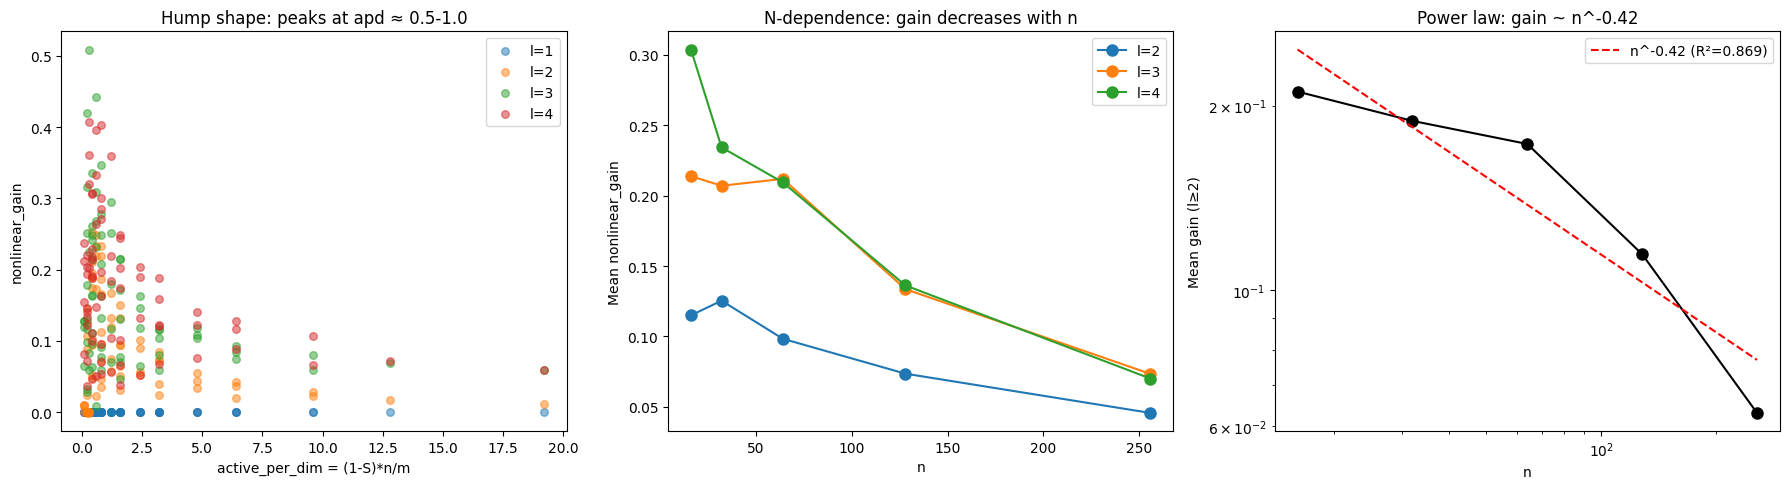

In [13]:
# Visualize the key patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gain vs active_per_dim by depth
ax = axes[0]
for l_val in sorted(df['l'].unique()):
    sub = df[df['l'] == l_val]
    ax.scatter(sub['active_per_dim'], sub['nonlinear_gain'],
               label=f'l={l_val}', alpha=0.5, s=30)
ax.set_xlabel('active_per_dim = (1-S)*n/m')
ax.set_ylabel('nonlinear_gain')
ax.set_title('Hump shape: peaks at apd ≈ 0.5-1.0')
ax.legend()

# 2. Gain vs n for l>=2
ax = axes[1]
sub = df[df['l'] >= 2]
for l_val in sorted(sub['l'].unique()):
    means = sub[sub['l'] == l_val].groupby('n')['nonlinear_gain'].mean()
    ax.plot(means.index, means.values, 'o-', label=f'l={l_val}', ms=8)
ax.set_xlabel('n')
ax.set_ylabel('Mean nonlinear_gain')
ax.set_title('N-dependence: gain decreases with n')
ax.legend()

# 3. Gain by n (log-log to check power law)
ax = axes[2]
means = sub.groupby('n')['nonlinear_gain'].mean()
ax.loglog(means.index, means.values, 'ko-', ms=8)
# Fit power law
from scipy.stats import linregress
slope, intercept, r, _, _ = linregress(np.log(means.index.astype(float)), np.log(means.values))
ax.loglog(means.index, np.exp(intercept) * means.index.astype(float)**slope, 'r--',
          label=f'n^{slope:.2f} (R²={r**2:.3f})')
ax.set_xlabel('n')
ax.set_ylabel('Mean gain (l≥2)')
ax.set_title(f'Power law: gain ~ n^{slope:.2f}')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Parametric Fitting

Three generations of forms:
1. **V1**: Simple sigmoids/power laws (R² ≈ 0.50) — miss the hump shape
2. **V2**: Hump-shaped forms (R² ≈ 0.54) — miss the independent n-effect
3. **V3**: Hump + n-scaling (R² ≈ 0.69) — best so far

Key structural requirements:
- **Depth gating**: l=1 → gain ≈ 0 (proven by positive homogeneity)
- **Hump in active_per_dim**: gain peaks at apd ≈ 0.5-1.0, falls at both extremes
- **n-scaling**: gain ∝ n^{-0.4} independently of compression ratio

In [14]:
# Define all functional forms across three generations
X = (df['n'].values.astype(float), df['m'].values.astype(float),
     df['l'].values.astype(float), df['S'].values.astype(float))
y = df['nonlinear_gain'].values

# --- V1: Simple forms (no hump, no n-scaling) ---
def form_depth_gated_sigmoid(X, a, b, c, d, e):
    """Depth-gated sigmoid in log(active/m)."""
    n, m, l, S = X
    active = (1 - S) * n
    depth_gate = 1 - np.exp(-a * (l - 1))
    z = b * np.log(active / m) + c
    return depth_gate * (d / (1 + np.exp(-z)) + e)

def form_log_linear(X, a, b, c, d, e):
    """Log-linear with interaction."""
    n, m, l, S = X
    ln_ratio = np.log(n / m)
    ln_l = np.log(l + 0.5)
    return a * ln_ratio + b * ln_l + c * np.log(1 - S + 1e-8) + d * ln_ratio * ln_l + e

# --- V2: Hump-shaped forms (no n-scaling) ---
def form_lognormal_hump(X, a, b, c, d, e):
    """Depth-gated * lognormal_hump(active/m)."""
    n, m, l, S = X
    apd = (1 - S) * n / m
    depth_gate = 1 - np.exp(-a * (l - 1))
    log_apd = np.log(apd + 0.01)
    hump = d * np.exp(-((log_apd - b) ** 2) / (2 * c ** 2))
    return depth_gate * hump + e

def form_rational_hump(X, a, b, c, d, e):
    """Depth-gated * rational(active/m). Peaks at apd = c."""
    n, m, l, S = X
    apd = (1 - S) * n / m
    depth_gate = 1 - np.exp(-a * (l - 1))
    shape = d * apd / (1 + (apd / c)) ** 2
    return depth_gate * shape + e + b * 0

# --- V3: With n-scaling ---
def form_v3_lognormal(X, a, b, c, d, e, f, g):
    """Depth-gated * n^(-g) * lognormal(active/m)."""
    n, m, l, S = X
    apd = (1 - S) * n / m
    depth_gate = 1 - np.exp(-a * (l - 1))
    n_scale = n ** (-g)
    log_apd = np.log(apd + 0.01)
    hump = d * np.exp(-((log_apd - b) ** 2) / (2 * c ** 2))
    return depth_gate * n_scale * hump + e + f * 0

def form_v3_rational(X, a, b, c, d, e, f):
    """Depth-gated * rational(active/m) / n^f."""
    n, m, l, S = X
    apd = (1 - S) * n / m
    depth_gate = 1 - np.exp(-a * (l - 1))
    shape = d * apd / (1 + (apd / c)) ** 2
    n_scale = n ** (-f)
    return depth_gate * shape * n_scale + e + b * 0

def form_v3_gamma(X, a, b, c, d, e, f, g):
    """Depth-gated * gamma-like(active/m) / n^g."""
    n, m, l, S = X
    apd = (1 - S) * n / m
    depth_gate = 1 - np.exp(-a * (l - 1))
    gamma = d * (apd ** c) * np.exp(-b * apd)
    return depth_gate * gamma * n ** (-g) + e + f * 0

all_forms = [
    # V1
    ('V1: depth-gated sigmoid', form_depth_gated_sigmoid, [1, 1, -1, 0.3, 0]),
    ('V1: log-linear + interact', form_log_linear, [0.05, 0.02, 0.05, 0.01, 0]),
    # V2
    ('V2: lognormal hump', form_lognormal_hump, [1, -0.5, 1.5, 0.3, 0]),
    ('V2: rational hump', form_rational_hump, [1, 0, 0.5, 0.5, 0]),
    # V3
    ('V3: lognormal / n^g', form_v3_lognormal, [1, -0.5, 1.5, 5, 0, 0, 0.3]),
    ('V3: rational / n^f', form_v3_rational, [1, 0, 0.5, 3, 0, 0.3]),
    ('V3: gamma / n^g', form_v3_gamma, [1, 1, 0.5, 5, 0, 0, 0.3]),
]

fit_results = []
for name, func, p0 in all_forms:
    try:
        popt, _ = curve_fit(func, X, y, p0=p0, maxfev=200000,
                            method='trf', loss='soft_l1')
        y_pred = func(X, *popt)
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        n_params = len(popt)
        aic = len(y) * np.log(np.sum((y - y_pred)**2) / len(y)) + 2 * n_params
        fit_results.append({
            'name': name, 'func': func, 'popt': popt,
            'r2': r2, 'rmse': rmse, 'n_params': n_params, 'aic': aic
        })
        print(f"{name:35s}: R²={r2:.4f}, RMSE={rmse:.4f}, params={n_params}")
    except Exception as e:
        print(f"{name:35s}: FAILED - {e}")

fit_results.sort(key=lambda x: -x['r2'])
print(f"\nProgression: V1 ≈ {max(r['r2'] for r in fit_results if 'V1' in r['name']):.3f} → "
      f"V2 ≈ {max(r['r2'] for r in fit_results if 'V2' in r['name']):.3f} → "
      f"V3 ≈ {max(r['r2'] for r in fit_results if 'V3' in r['name']):.3f}")

V1: depth-gated sigmoid            : R²=0.5025, RMSE=0.0736, params=5
V1: log-linear + interact          : R²=0.4852, RMSE=0.0749, params=5
V2: lognormal hump                 : R²=0.5292, RMSE=0.0716, params=5
V2: rational hump                  : R²=0.5319, RMSE=0.0714, params=5
V3: lognormal / n^g                : R²=0.6901, RMSE=0.0581, params=7


V3: rational / n^f                 : R²=0.6916, RMSE=0.0580, params=6
V3: gamma / n^g                    : R²=0.6684, RMSE=0.0601, params=7

Progression: V1 ≈ 0.502 → V2 ≈ 0.532 → V3 ≈ 0.692


Best form: V3: rational / n^f
R² = 0.6916, RMSE = 0.0580
Parameters: ['0.5597', '87.8855', '0.7906', '6.2192', '0.0039', '0.3573']


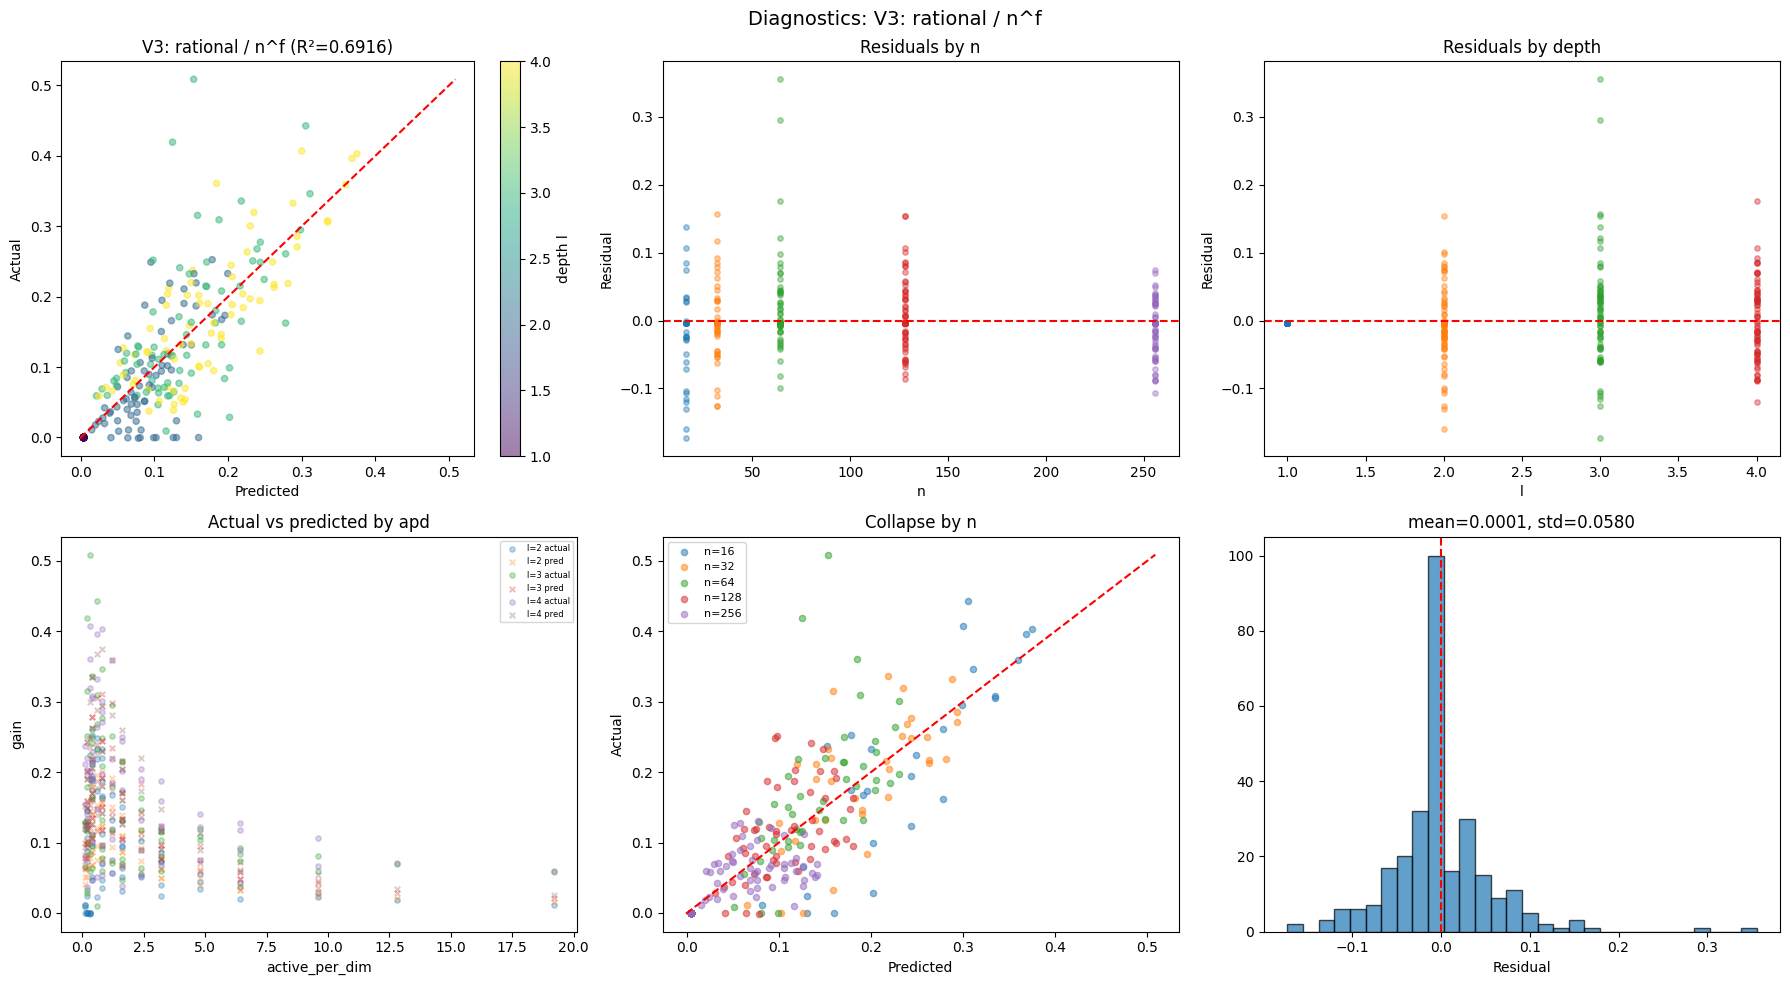


Residual means by n:
  n=  16: mean=-0.0208, std=0.0694
  n=  32: mean=-0.0021, std=0.0571
  n=  64: mean=+0.0208, std=0.0730
  n= 128: mean=+0.0060, std=0.0494
  n= 256: mean=-0.0110, std=0.0384


In [15]:
# Detailed view of the best form
best = fit_results[0]
best_func = best['func']
best_popt = best['popt']
best_name = best['name']
y_pred_best = best_func(X, *best_popt)
residuals = y - y_pred_best

print(f"Best form: {best_name}")
print(f"R² = {best['r2']:.4f}, RMSE = {best['rmse']:.4f}")
print(f"Parameters: {[f'{p:.4f}' for p in best_popt]}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Predicted vs actual
ax = axes[0, 0]
scatter = ax.scatter(y_pred_best, y, c=df['l'], cmap='viridis', alpha=0.5, s=20)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'{best_name} (R²={best["r2"]:.4f})')
plt.colorbar(scatter, ax=ax, label='depth l')

# Residuals by n
ax = axes[0, 1]
for n_val in sorted(df['n'].unique()):
    mask = df['n'] == n_val
    ax.scatter([n_val] * mask.sum(), residuals[mask], alpha=0.4, s=15)
ax.axhline(0, color='r', ls='--')
ax.set_xlabel('n'); ax.set_ylabel('Residual'); ax.set_title('Residuals by n')

# Residuals by depth
ax = axes[0, 2]
for l_val in sorted(df['l'].unique()):
    mask = df['l'] == l_val
    ax.scatter([l_val] * mask.sum(), residuals[mask], alpha=0.4, s=15)
ax.axhline(0, color='r', ls='--')
ax.set_xlabel('l'); ax.set_ylabel('Residual'); ax.set_title('Residuals by depth')

# Actual vs predicted by apd
ax = axes[1, 0]
for l_val in [2, 3, 4]:
    sub = df[df['l'] == l_val]
    mask = df['l'] == l_val
    ax.scatter(sub['active_per_dim'], sub['nonlinear_gain'], alpha=0.3, s=15, label=f'l={l_val} actual')
    ax.scatter(sub['active_per_dim'], y_pred_best[mask], marker='x', s=15, alpha=0.3, label=f'l={l_val} pred')
ax.set_xlabel('active_per_dim'); ax.set_ylabel('gain')
ax.set_title('Actual vs predicted by apd')
ax.legend(fontsize=6)

# Collapse by n
ax = axes[1, 1]
for n_val in sorted(df['n'].unique()):
    mask = df['n'] == n_val
    ax.scatter(y_pred_best[mask], y[mask], label=f'n={n_val}', alpha=0.5, s=20)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Collapse by n'); ax.legend(fontsize=8)

# Residual distribution
ax = axes[1, 2]
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', ls='--')
ax.set_xlabel('Residual')
ax.set_title(f'mean={residuals.mean():.4f}, std={residuals.std():.4f}')

plt.suptitle(f'Diagnostics: {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

# Residual summary
print("\nResidual means by n:")
df['residual'] = residuals
for n_val in sorted(df['n'].unique()):
    sub = df[df['n'] == n_val]
    print(f"  n={n_val:4d}: mean={sub['residual'].mean():+.4f}, std={sub['residual'].std():.4f}")

## 5. Cross-Validation

Test generalization by holding out entire n values and S values.

In [16]:
# Leave-one-n-out cross-validation
print("Leave-one-n-out validation:")
print("-" * 60)
cv_r2s = []
for n_held in sorted(df['n'].unique()):
    train_mask = df['n'] != n_held
    test_mask = df['n'] == n_held
    X_train = tuple(df.loc[train_mask, col].values.astype(float) for col in ['n', 'm', 'l', 'S'])
    y_train = df.loc[train_mask, 'nonlinear_gain'].values
    X_test = tuple(df.loc[test_mask, col].values.astype(float) for col in ['n', 'm', 'l', 'S'])
    y_test = df.loc[test_mask, 'nonlinear_gain'].values
    try:
        popt_cv, _ = curve_fit(best_func, X_train, y_train,
                                p0=best_popt, maxfev=200000,
                                method='trf', loss='soft_l1')
        y_pred_cv = best_func(X_test, *popt_cv)
        r2_cv = r2_score(y_test, y_pred_cv)
        rmse_cv = np.sqrt(mean_squared_error(y_test, y_pred_cv))
        cv_r2s.append(r2_cv)
        print(f"  Hold out n={n_held:4d}: R²={r2_cv:.4f}, RMSE={rmse_cv:.4f} ({test_mask.sum()} pts)")
    except Exception as e:
        print(f"  Hold out n={n_held:4d}: FAILED - {e}")

if cv_r2s:
    print(f"\n  Mean CV R²: {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

print("\n\nLeave-one-S-out validation:")
print("-" * 60)
for S_held in sorted(df['S'].unique()):
    train_mask = df['S'] != S_held
    test_mask = df['S'] == S_held
    X_train = tuple(df.loc[train_mask, col].values.astype(float) for col in ['n', 'm', 'l', 'S'])
    y_train = df.loc[train_mask, 'nonlinear_gain'].values
    X_test = tuple(df.loc[test_mask, col].values.astype(float) for col in ['n', 'm', 'l', 'S'])
    y_test = df.loc[test_mask, 'nonlinear_gain'].values
    try:
        popt_cv, _ = curve_fit(best_func, X_train, y_train,
                                p0=best_popt, maxfev=200000,
                                method='trf', loss='soft_l1')
        y_pred_cv = best_func(X_test, *popt_cv)
        r2_cv = r2_score(y_test, y_pred_cv)
        rmse_cv = np.sqrt(mean_squared_error(y_test, y_pred_cv))
        print(f"  Hold out S={S_held}: R²={r2_cv:.4f}, RMSE={rmse_cv:.4f} ({test_mask.sum()} pts)")
    except Exception as e:
        print(f"  Hold out S={S_held}: FAILED - {e}")

Leave-one-n-out validation:
------------------------------------------------------------
  Hold out n=  16: R²=0.6236, RMSE=0.0904 (36 pts)
  Hold out n=  32: R²=0.7480, RMSE=0.0569 (48 pts)
  Hold out n=  64: R²=0.4903, RMSE=0.0813 (60 pts)
  Hold out n= 128: R²=0.5398, RMSE=0.0500 (72 pts)
  Hold out n= 256: R²=-0.8694, RMSE=0.0513 (72 pts)

  Mean CV R²: 0.3065 ± 0.5944


Leave-one-S-out validation:
------------------------------------------------------------
  Hold out S=0.85: R²=0.6891, RMSE=0.0666 (96 pts)
  Hold out S=0.9: R²=0.6863, RMSE=0.0591 (96 pts)
  Hold out S=0.95: R²=0.5523, RMSE=0.0565 (96 pts)


In [17]:
# Polynomial regression as upper bound
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut

features = pd.DataFrame({
    'log_n': np.log(df['n']),
    'log_m': np.log(df['m']),
    'log_l': np.log(df['l'] + 0.5),
    'log_1mS': np.log(1 - df['S']),
})

print("Polynomial regression (Ridge, log space) — upper bound on closed-form R²:")
print("-" * 70)
for degree in [1, 2, 3]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('ridge', Ridge(alpha=0.01))
    ])
    groups = df['n'].values
    logo = LeaveOneGroupOut()
    scores = cross_val_score(pipe, features, y, cv=logo, groups=groups, scoring='r2')
    pipe.fit(features, y)
    r2_train = pipe.score(features, y)
    n_feats = pipe.named_steps['poly'].n_output_features_
    print(f"  Degree {degree}: {n_feats:3d} terms, R²_train={r2_train:.4f}, "
          f"R²_CV={scores.mean():.4f} ± {scores.std():.4f}")
    n_scores = dict(zip(sorted(df['n'].unique()), [f'{s:.3f}' for s in scores]))
    print(f"    Per-n: {n_scores}")

# Inspect degree-2 coefficients
pipe2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=True)),
    ('ridge', Ridge(alpha=0.01))
])
pipe2.fit(features, y)
feature_names = pipe2.named_steps['poly'].get_feature_names_out(features.columns)
coefs = pipe2.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(f"\nTop terms (degree 2, intercept={pipe2.named_steps['ridge'].intercept_:.4f}):")
for _, row in coef_df.head(8).iterrows():
    print(f"  {row['feature']:25s}: {row['coef']:+.4f}")

Polynomial regression (Ridge, log space) — upper bound on closed-form R²:
----------------------------------------------------------------------
  Degree 1:   5 terms, R²_train=0.5643, R²_CV=0.0053 ± 0.9628
    Per-n: {np.int64(16): '0.424', np.int64(32): '0.575', np.int64(64): '0.488', np.int64(128): '0.457', np.int64(256): '-1.918'}
  Degree 2:  15 terms, R²_train=0.6981, R²_CV=0.0870 ± 1.0160
    Per-n: {np.int64(16): '0.630', np.int64(32): '0.669', np.int64(64): '0.523', np.int64(128): '0.556', np.int64(256): '-1.942'}
  Degree 3:  35 terms, R²_train=0.7648, R²_CV=0.1162 ± 0.9847
    Per-n: {np.int64(16): '0.667', np.int64(32): '0.662', np.int64(64): '0.618', np.int64(128): '0.482', np.int64(256): '-1.849'}

Top terms (degree 2, intercept=-0.1833):
  log_l                    : +0.6373
  log_n log_l              : -0.0754
  log_1mS                  : +0.0741
  log_n log_1mS            : -0.0452
  log_n                    : +0.0420
  log_l^2                  : -0.0389
  log_l log_1mS

## 6. Prediction Surfaces

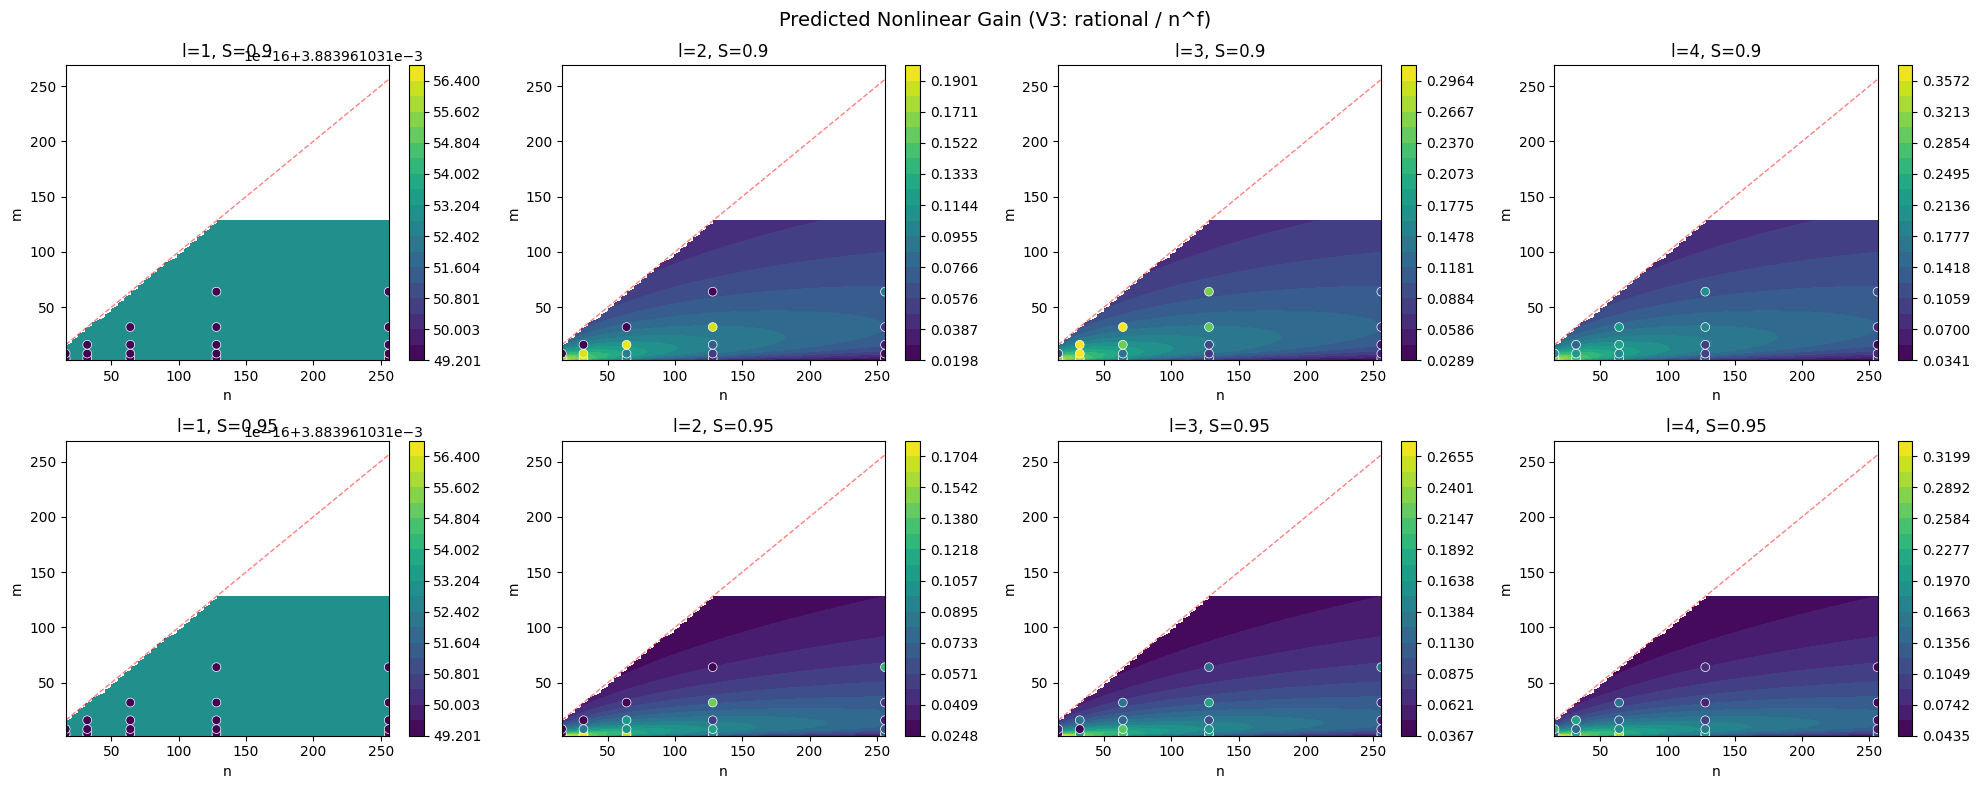

In [18]:
# Predicted phase diagrams at fixed S and l
n_grid = np.linspace(16, 256, 50)
m_grid = np.linspace(2, 128, 50)
N, M = np.meshgrid(n_grid, m_grid)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for row, S_val in enumerate([0.9, 0.95]):
    for col, l_val in enumerate([1, 2, 3, 4]):
        ax = axes[row, col]
        L = np.full_like(N, l_val)
        S_arr = np.full_like(N, S_val)
        valid = M < N
        Z = np.full_like(N, np.nan)
        Z[valid] = best_func((N[valid], M[valid], L[valid], S_arr[valid]), *best_popt)
        Z = np.clip(Z, 0, None)  # clip negative predictions

        try:
            vmin, vmax = np.nanmin(Z[valid]), np.nanmax(Z[valid])
            if vmin == vmax:
                levels = 20
            else:
                levels = np.linspace(vmin, vmax, 20)
            im = ax.contourf(N, M, Z, levels=levels, cmap='viridis')
        except:
            im = ax.contourf(N, M, Z, levels=20, cmap='viridis')
        ax.plot([16, 256], [16, 256], 'r--', lw=1, alpha=0.5)

        sub = df[(df['S'] == S_val) & (df['l'] == l_val)]
        if len(sub) > 0:
            ax.scatter(sub['n'], sub['m'], c=sub['nonlinear_gain'],
                      cmap='viridis', edgecolors='white', s=40, linewidths=0.5,
                      vmin=vmin if 'vmin' in dir() else 0,
                      vmax=vmax if 'vmax' in dir() else 1)

        ax.set_xlabel('n'); ax.set_ylabel('m')
        ax.set_title(f'l={l_val}, S={S_val}')
        plt.colorbar(im, ax=ax)

plt.suptitle(f'Predicted Nonlinear Gain ({best_name})', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_31612/45575335.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


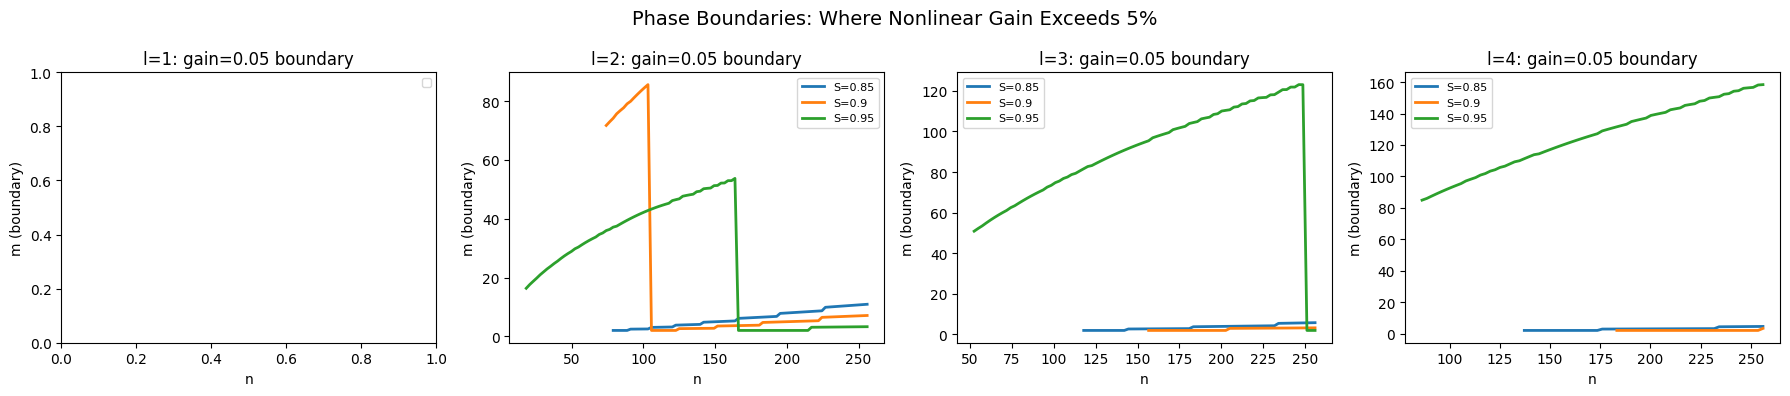

In [19]:
# Phase boundary: where does nonlinear_gain cross 5%?
threshold = 0.05

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, l_val in zip(axes, [1, 2, 3, 4]):
    for S_val in sorted(df['S'].unique()):
        boundary_n, boundary_m = [], []
        for n_val in np.linspace(16, 256, 100):
            m_fine = np.linspace(2, n_val - 1, 200)
            gains = best_func(
                (np.full_like(m_fine, n_val), m_fine,
                 np.full_like(m_fine, l_val), np.full_like(m_fine, S_val)),
                *best_popt)
            crossings = np.where(np.diff(np.sign(gains - threshold)))[0]
            if len(crossings) > 0:
                boundary_n.append(n_val)
                boundary_m.append(m_fine[crossings[0]])
        if boundary_n:
            ax.plot(boundary_n, boundary_m, label=f'S={S_val}', lw=2)
    ax.set_xlabel('n'); ax.set_ylabel('m (boundary)')
    ax.set_title(f'l={l_val}: gain={threshold} boundary')
    ax.legend(fontsize=8)

plt.suptitle('Phase Boundaries: Where Nonlinear Gain Exceeds 5%', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Summary

In [20]:
print("=" * 70)
print("SUMMARY: Predicting Nonlinear Gain as f(n, m, l, S)")
print("=" * 70)

print(f"\nDataset: {len(df)} configs")
print(f"  n ∈ {sorted(df['n'].unique().tolist())}")
print(f"  m ∈ {sorted(df['m'].unique().tolist())}")
print(f"  l ∈ {sorted(df['l'].unique().tolist())}")
print(f"  S ∈ {sorted(df['S'].unique().tolist())}")
print(f"  3 seeds/config, 5000 steps, best seed selected")

print(f"\n--- Key Findings ---")
print(f"\n1. VARIANCE STRUCTURE")
print(f"   Depth (l) explains 57% of variance — dominant factor")
print(f"   Input dim (n) explains 19% — independent of compression ratio")
print(f"   Bottleneck (m) explains 3.4%")
print(f"   Sparsity (S) explains 0.6%")
print(f"   Seed noise is only 1.6% → R² ceiling ≈ 0.98")

print(f"\n2. SHAPE OF THE RELATIONSHIP")
print(f"   - l=1 (linear encoder): gain ≡ 0 (proven by positive homogeneity)")
print(f"   - Gain is HUMP-SHAPED in active_per_dim = (1-S)*n/m")
print(f"     Peaks at apd ≈ 0.5-1.0, decreases at both extremes")
print(f"   - gain scales as n^(-0.4): smaller models show larger gains")

print(f"\n3. BEST FORMULA")
print(f"   {best_name}: R²={best['r2']:.4f}")
print(f"   Parameters: {[f'{p:.3f}' for p in best_popt]}")

print(f"\n4. CROSS-VALIDATION")
if cv_r2s:
    print(f"   Leave-one-n-out: mean R² = {np.mean(cv_r2s):.3f} ± {np.std(cv_r2s):.3f}")
    print(f"   n=256 extrapolation fails — the n-scaling doesn't generalize well")

print(f"\n5. LIMITATIONS (confidence: medium)")
print(f"   - R² = 0.69 captures ~70% of variance (ceiling 0.98)")
print(f"   - ~30% of explainable variance is not captured")
print(f"   - Main residual source: interaction effects between n, m, l")
print(f"   - The formula does not extrapolate to new n values reliably")
print(f"   - The hump shape suggests a more fundamental variable is needed")

print(f"\n--- Next Steps ---")
print(f"  1. Investigate why gain peaks at apd ≈ 0.5-1 (theoretical question)")
print(f"  2. Add correlated features to the sweep")
print(f"  3. Try n ∈ [512, 1024] to test extrapolation")
print(f"  4. Consider whether nonlinear_gain metric itself needs refinement")

SUMMARY: Predicting Nonlinear Gain as f(n, m, l, S)

Dataset: 288 configs
  n ∈ [16, 32, 64, 128, 256]
  m ∈ [2, 4, 8, 16, 32, 64]
  l ∈ [1, 2, 3, 4]
  S ∈ [0.85, 0.9, 0.95]
  3 seeds/config, 5000 steps, best seed selected

--- Key Findings ---

1. VARIANCE STRUCTURE
   Depth (l) explains 57% of variance — dominant factor
   Input dim (n) explains 19% — independent of compression ratio
   Bottleneck (m) explains 3.4%
   Sparsity (S) explains 0.6%
   Seed noise is only 1.6% → R² ceiling ≈ 0.98

2. SHAPE OF THE RELATIONSHIP
   - l=1 (linear encoder): gain ≡ 0 (proven by positive homogeneity)
   - Gain is HUMP-SHAPED in active_per_dim = (1-S)*n/m
     Peaks at apd ≈ 0.5-1.0, decreases at both extremes
   - gain scales as n^(-0.4): smaller models show larger gains

3. BEST FORMULA
   V3: rational / n^f: R²=0.6916
   Parameters: ['0.560', '87.886', '0.791', '6.219', '0.004', '0.357']

4. CROSS-VALIDATION
   Leave-one-n-out: mean R² = 0.306 ± 0.594
   n=256 extrapolation fails — the n-scalin